In [53]:
# ─────────────────────────────────────────────
# [C1] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
!pip install scikit-learn xgboost matplotlib seaborn -q
import platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import matplotlib.font_manager as fm

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

import sklearn, xgboost
print("준비 완료 ✓")
print(f"- scikit-learn {sklearn.__version__}")
print(f"- xgboost      {xgboost.__version__}")

준비 완료 ✓
- scikit-learn 1.9.0
- xgboost      3.4.0


In [54]:
# ─────────────────────────────────────────────
# [C2] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터 데이터 로드 — 분류(유방암) + 회귀(당뇨), 전부 sklearn 내장 (인터넷 불필요)
# ─────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split

# 메인 분류 데이터: 유방암 진단 (이진분류) — 🎬 오늘의 무대에서 소개한 공개 실습 데이터
cancer = load_breast_cancer(as_frame=True)
Xc, yc = cancer.data, cancer.target
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc)

print(f"분류 데이터(유방암): 학습 {Xc_tr.shape[0]} / 테스트 {Xc_te.shape[0]} | 피처 {Xc.shape[1]}개")
print(f"  클래스: {dict(zip(['악성(0)','양성(1)'], np.bincount(yc)))}")

분류 데이터(유방암): 학습 455 / 테스트 114 | 피처 30개
  클래스: {'악성(0)': np.int64(212), '양성(1)': np.int64(357)}


In [55]:
# ─────────────────────────────────────────────
# [C3] ◀ Part 1 · 🔍 자세히 알아보기 — 분할 기준(불순도와 정보획득) 지니 불순도를 직접 계산해 보기
# ─────────────────────────────────────────────
def gini(counts):
    counts = np.array(counts, dtype=float)
    p = counts / counts.sum()
    return 1 - np.sum(p ** 2)

print("순수(5:0):", round(gini([5, 0]), 3), "→ 완전 순수")
print("반반(5:5):", round(gini([5, 5]), 3), "→ 가장 불순")
print("치우침(8:2):", round(gini([8, 2]), 3))

# 분할 전후 정보획득 예시: 루트(5:5) → 왼쪽(5:0)/오른쪽(0:5)
before = gini([5, 5])
after = 0.5 * gini([5, 0]) + 0.5 * gini([0, 5])   # 가중 평균
print(f"\n정보획득 = {before:.3f} - {after:.3f} = {before-after:.3f}  (완벽 분할!)")

순수(5:0): 0.0 → 완전 순수
반반(5:5): 0.5 → 가장 불순
치우침(8:2): 0.32

정보획득 = 0.500 - 0.000 = 0.500  (완벽 분할!)


In [56]:
# ─────────────────────────────────────────────
# [C3] ◀ Part 1 · 🔍 자세히 알아보기 — 분할 기준(불순도와 정보획득) 지니 불순도를 직접 계산해 보기
# ─────────────────────────────────────────────
def gini(counts):
    counts = np.array(counts, dtype=float)
    p = counts / counts.sum()
    return 1 - np.sum(p ** 2)

print("순수(5:0):", round(gini([5, 0]), 3), "→ 완전 순수")
print("반반(5:5):", round(gini([5, 5]), 3), "→ 가장 불순")
print("치우침(8:2):", round(gini([8, 2]), 3))

# 분할 전후 정보획득 예시: 루트(5:5) → 왼쪽(5:0)/오른쪽(0:5)
before = gini([5, 5])
after = 0.5 * gini([5, 0]) + 0.5 * gini([0, 5])   # 가중 평균
print(f"\n정보획득 = {before:.3f} - {after:.3f} = {before-after:.3f}  (완벽 분할!)")

순수(5:0): 0.0 → 완전 순수
반반(5:5): 0.5 → 가장 불순
치우침(8:2): 0.32

정보획득 = 0.500 - 0.000 = 0.500  (완벽 분할!)


테스트 정확도 = 0.939


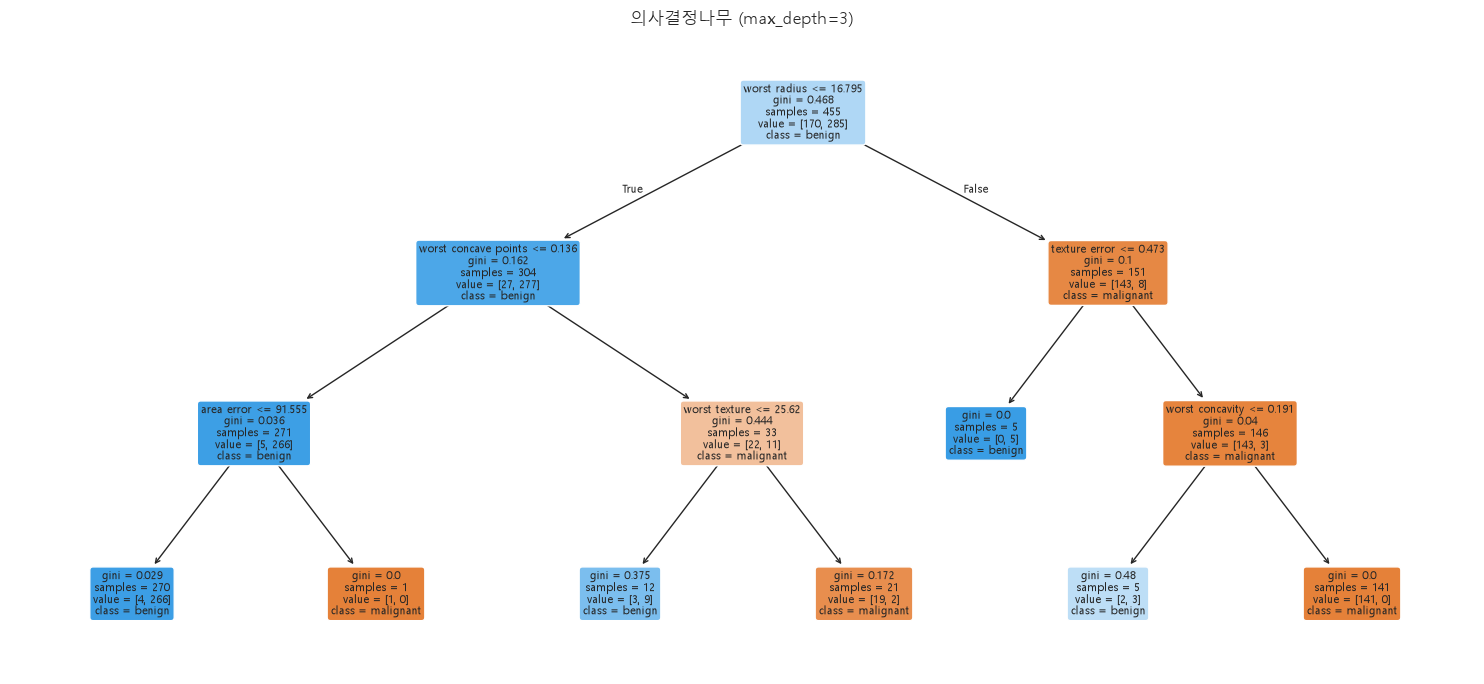

In [57]:
# [C4] ◀ Part 1 · 📊 데이터로 확인해 봅시다 — 트리를 학습하고 그려보기
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree.fit(Xc_tr, yc_tr)
print(f"테스트 정확도 = {tree.score(Xc_te, yc_te):.3f}")

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(tree, feature_names=Xc.columns, class_names=["malignant", "benign"],
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title("의사결정나무 (max_depth=3)")
plt.tight_layout(); plt.show()

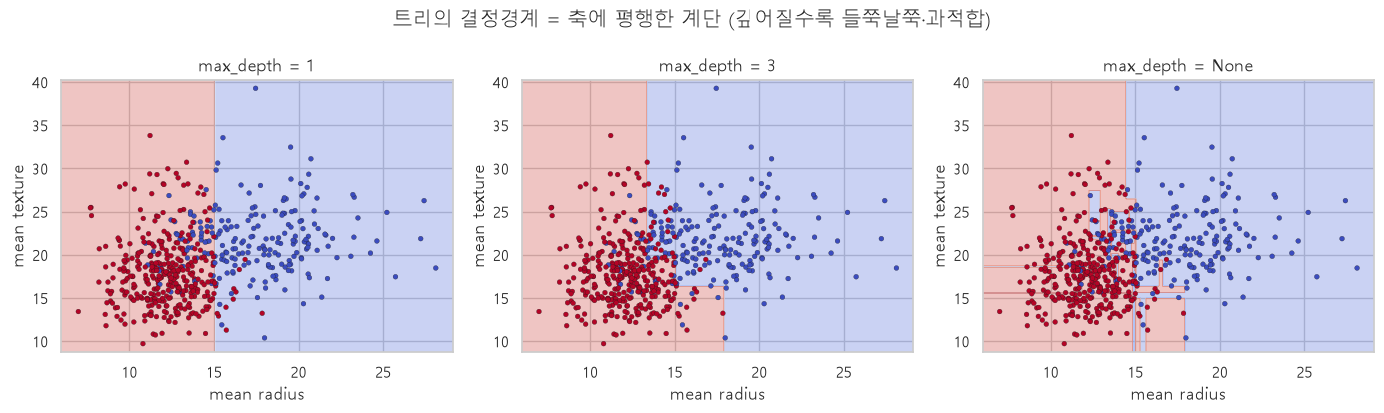

In [58]:
# ─────────────────────────────────────────────
# [C5] ◀ Part 1 · 📊 데이터로 확인해 봅시다 — 트리를 학습하고 그려보기 단일 트리의 결정경계 (계단 모양) — 깊이별 비교
# ─────────────────────────────────────────────
feats = ["mean radius", "mean texture"]
X2 = Xc[feats].values
import numpy as np
xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-1, X2[:,0].max()+1, 300),
                     np.linspace(X2[:,1].min()-1, X2[:,1].max()+1, 300))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, d in zip(axes, [1, 3, None]):
    t = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X2, yc)
    zz = t.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap="coolwarm")
    ax.scatter(X2[:,0], X2[:,1], c=yc, cmap="coolwarm", s=12, edgecolor="k", linewidth=0.2)
    ax.set_title(f"max_depth = {d}"); ax.set_xlabel(feats[0]); ax.set_ylabel(feats[1])
plt.suptitle("트리의 결정경계 = 축에 평행한 계단 (깊어질수록 들쭉날쭉·과적합)")
plt.tight_layout(); plt.show()

In [59]:
# [C6] ◀ Part 1 · ⌨️ 백문이 불여일타! (1) ⌨️ 백문이 불여일타! (1) — criterion을 entropy로 바꿔 비교

# 1) 분할 기준을 지니 대신 엔트로피로 바꿔(criterion="entropy") 트리를 다시 학습해보세요.
# 2) 지니 기준 트리와 테스트 정확도를 비교해보세요.

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree.fit(Xc_tr, yc_tr)
print(f"지니 기준 테스트 정확도 = {tree.score(Xc_te, yc_te):.3f}")

tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE, criterion="entropy")
tree.fit(Xc_tr, yc_tr)
print(f" 엔트로피 기준 테스트 정확도 = {tree.score(Xc_te, yc_te):.3f}")

지니 기준 테스트 정확도 = 0.939
 엔트로피 기준 테스트 정확도 = 0.947


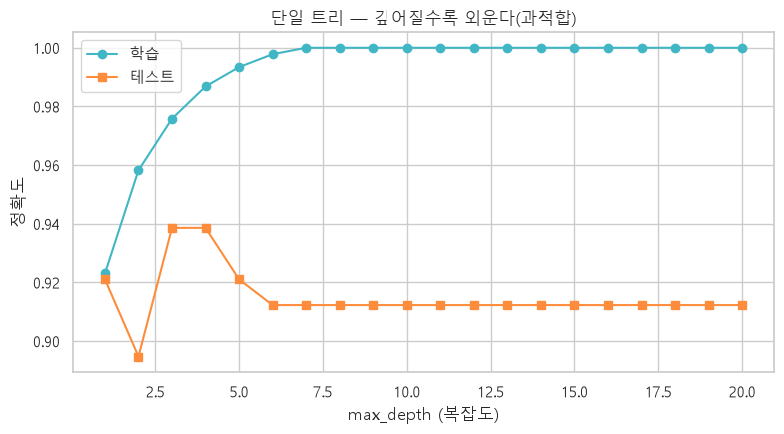

학습은 곧 1.0으로 수렴하지만 테스트는 정체합니다. 최적 깊이 ≈ 3


In [60]:
# ─────────────────────────────────────────────
# [C7] ◀ Part 2 · 📊 데이터로 확인해 봅시다 — 깊이를 키우면 무엇이 벌어지나 깊이를 키울수록 학습↑·테스트는 정체 → 과적합
# ─────────────────────────────────────────────
depths = range(1, 21)
tr, te = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
    tr.append(m.score(Xc_tr, yc_tr)); te.append(m.score(Xc_te, yc_te))

plt.figure(figsize=(8, 4.5))
plt.plot(list(depths), tr, "o-", label="학습", color="#41b6c4")
plt.plot(list(depths), te, "s-", label="테스트", color="#fd8d3c")
plt.xlabel("max_depth (복잡도)"); plt.ylabel("정확도")
plt.title("단일 트리 — 깊어질수록 외운다(과적합)")
plt.legend(); plt.tight_layout(); plt.show()

best = list(depths)[int(np.argmax(te))]
print(f"학습은 곧 1.0으로 수렴하지만 테스트는 정체합니다. 최적 깊이 ≈ {best}")

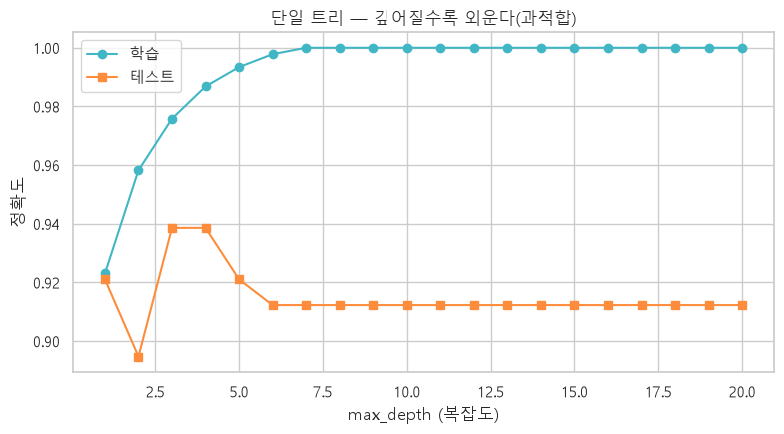

학습은 곧 1.0으로 수렴하지만 테스트는 정체합니다. 최적 깊이 ≈ 3


In [61]:
# [C8] ◀ Part 2 · ⌨️ 백문이 불여일타! (2) ⌨️ 백문이 불여일타! (2) — min_samples_leaf 효과 실험

# 여기에 코드를 작성하세요

depths = range(1, 21)
tr, te = [], []
for d in depths:
        m = DecisionTreeClassifier(min_samples_leaf=1, max_depth=d, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
        tr.append(m.score(Xc_tr, yc_tr)); te.append(m.score(Xc_te, yc_te))

plt.figure(figsize=(8, 4.5))
plt.plot(list(depths), tr, "o-", label="학습", color="#41b6c4")
plt.plot(list(depths), te, "s-", label="테스트", color="#fd8d3c")
plt.xlabel("max_depth (복잡도)"); plt.ylabel("정확도")
plt.title("단일 트리 — 깊어질수록 외운다(과적합)")
plt.legend(); plt.tight_layout(); plt.show()

best = list(depths)[int(np.argmax(te))]
print(f"학습은 곧 1.0으로 수렴하지만 테스트는 정체합니다. 최적 깊이 ≈ {best}")

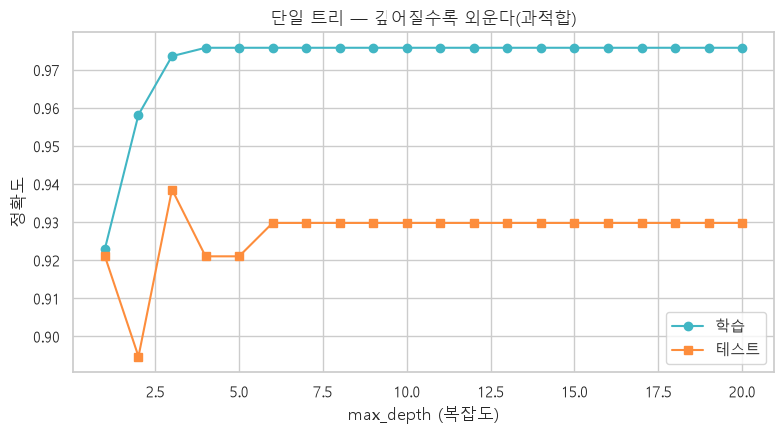

학습은 곧 1.0으로 수렴하지만 테스트는 정체합니다. 최적 깊이 ≈ 3


In [62]:
depths = range(1, 21)
tr, te = [], []
for d in depths:
    m = DecisionTreeClassifier(min_samples_leaf=5,max_depth=d, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
    tr.append(m.score(Xc_tr, yc_tr)); te.append(m.score(Xc_te, yc_te))

plt.figure(figsize=(8, 4.5))
plt.plot(list(depths), tr, "o-", label="학습", color="#41b6c4")
plt.plot(list(depths), te, "s-", label="테스트", color="#fd8d3c")
plt.xlabel("max_depth (복잡도)"); plt.ylabel("정확도")
plt.title("단일 트리 — 깊어질수록 외운다(과적합)")
plt.legend(); plt.tight_layout(); plt.show()

best = list(depths)[int(np.argmax(te))]
print(f"학습은 곧 1.0으로 수렴하지만 테스트는 정체합니다. 최적 깊이 ≈ {best}")

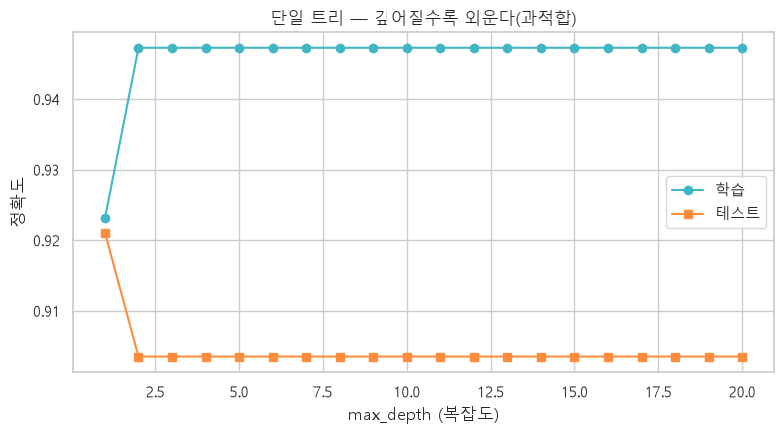

학습은 곧 1.0으로 수렴하지만 테스트는 정체합니다. 최적 깊이 ≈ 1


In [63]:
depths = range(1, 21)
tr, te = [], []
for d in depths:
    m = DecisionTreeClassifier(min_samples_leaf=20,max_depth=d, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
    tr.append(m.score(Xc_tr, yc_tr)); te.append(m.score(Xc_te, yc_te))

plt.figure(figsize=(8, 4.5))
plt.plot(list(depths), tr, "o-", label="학습", color="#41b6c4")
plt.plot(list(depths), te, "s-", label="테스트", color="#fd8d3c")
plt.xlabel("max_depth (복잡도)"); plt.ylabel("정확도")
plt.title("단일 트리 — 깊어질수록 외운다(과적합)")
plt.legend(); plt.tight_layout(); plt.show()

best = list(depths)[int(np.argmax(te))]
print(f"학습은 곧 1.0으로 수렴하지만 테스트는 정체합니다. 최적 깊이 ≈ {best}")

In [64]:
# [C9] ◀ Part 3 · 📊 데이터로 확인해 봅시다 — 부트스트랩과 랜덤포레스트 부트스트랩 한 번 — 중복과 누락 관찰
import numpy as np
np.random.seed(1)
original = np.arange(10)
boot = np.random.choice(original, size=10, replace=True)  # 복원추출
print("원본     :", original)
print("부트스트랩:", np.sort(boot))
print("뽑힌 고유값 개수:", len(set(boot)), "/ 10")
print(f"이론상 평균 포함 비율 ≈ {1-(1-1/len(original))**len(original):.0%}")

원본     : [0 1 2 3 4 5 6 7 8 9]
부트스트랩: [0 0 1 5 5 6 7 8 9 9]
뽑힌 고유값 개수: 7 / 10
이론상 평균 포함 비율 ≈ 65%


In [78]:
# ─────────────────────────────────────────────
# [C10] ◀ Part 3 · 📊 데이터로 확인해 봅시다 — 부트스트랩과 랜덤포레스트 단일 트리 vs 랜덤포레스트 — 직접 비교
# ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

single = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(Xc_tr, yc_tr)

print("단일 트리   : 학습 {:.3f} / 테스트 {:.3f}".format(single.score(Xc_tr,yc_tr), single.score(Xc_te,yc_te)))
print("랜덤포레스트 : 학습 {:.3f} / 테스트 {:.3f}".format(rf.score(Xc_tr,yc_tr), rf.score(Xc_te,yc_te)))
print("\n→ 둘 다 학습은 1.0에 가깝지만, 테스트 정확도와 '안정성'이 랜덤포레스트가 낫습니다.")


단일 트리   : 학습 1.000 / 테스트 0.912
랜덤포레스트 : 학습 1.000 / 테스트 0.947

→ 둘 다 학습은 1.0에 가깝지만, 테스트 정확도와 '안정성'이 랜덤포레스트가 낫습니다.


In [66]:
diabetes

{'data':           age       sex       bmi        bp        s1        s2        s3  \
 0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
 1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
 2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
 3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
 4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
 ..        ...       ...       ...       ...       ...       ...       ...   
 437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
 438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
 439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
 440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
 441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   
 
            s4        s5        s6  
 0   -0.002592  0

## [문제]
- 1) 랜덤포레스트는 회귀에도 됩니다 — RandomForestRegressor로 당뇨 진행도(앞서 배운 회귀 문제)를 예측해보세요.
- 2) 단일 트리 회귀(DecisionTreeRegressor)와 테스트 R²를 비교해보세요.

In [67]:
from sklearn.model_selection import train_test_split

diabetes = load_diabetes(as_frame=True)
Xc_1, yc_1 = diabetes.data, diabetes.target
Xc_tr_1, Xc_te_1, yc_tr_1, yc_te_1 = train_test_split(
    Xc_1, yc_1, test_size=0.2, random_state=RANDOM_STATE)


In [77]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

single = DecisionTreeRegressor(random_state=RANDOM_STATE).fit(Xc_tr_1, yc_tr_1)
rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(Xc_tr_1, yc_tr_1)

print("단일 트리   : 학습 {:.3f} / 테스트 {:.3f}".format(single.score(Xc_tr_1,yc_tr_1), single.score(Xc_te_1,yc_te_1)))
print("랜덤포레스트 : 학습 {:.3f} / 테스트 {:.3f}".format(rf.score(Xc_tr_1,yc_tr_1), rf.score(Xc_te_1,yc_te_1)))
print("\n→ 둘 다 학습은 1.0에 가깝지만, 테스트 R²와 '안정성'이 랜덤포레스트가 낫습니다.")

단일 트리   : 학습 1.000 / 테스트 0.061
랜덤포레스트 : 학습 0.924 / 테스트 0.434

→ 둘 다 학습은 1.0에 가깝지만, 테스트 R²와 '안정성'이 랜덤포레스트가 낫습니다.


In [69]:
# ─────────────────────────────────────────────
# [C13] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 AdaBoost — Stump를 순차로 쌓기
# ─────────────────────────────────────────────
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
print(f"AdaBoost 테스트 정확도 = {ada.score(Xc_te, yc_te):.3f}")

AdaBoost 테스트 정확도 = 0.965


In [70]:
# ─────────────────────────────────────────────
# [C14] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 Gradient Boosting — 잔차를 순차로 보정
# ─────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=3, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
print(f"Gradient Boosting 테스트 정확도 = {gbm.score(Xc_te, yc_te):.3f}")

Gradient Boosting 테스트 정확도 = 0.956


In [71]:
# ─────────────────────────────────────────────
# [C15] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 XGBoost — 정규화된 부스팅
# ─────────────────────────────────────────────
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4,
                    reg_lambda=1.0, random_state=RANDOM_STATE, eval_metric="logloss")
xgb.fit(Xc_tr, yc_tr)
print(f"XGBoost 테스트 정확도 = {xgb.score(Xc_te, yc_te):.3f}")

XGBoost 테스트 정확도 = 0.947


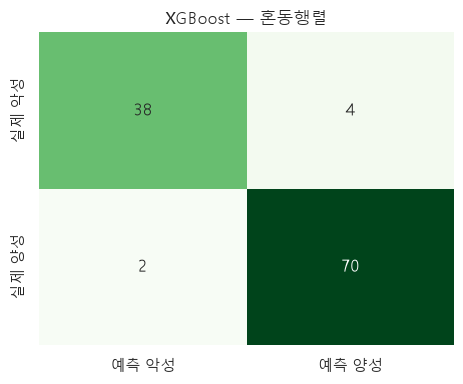

대각선이 정답. 이후 이 표로 정밀도·재현율을 계산합니다.


In [72]:
# [C16] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 XGBoost 혼동행렬 — 무엇을 맞히고 틀렸나
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(yc_te, xgb.predict(Xc_te))
fig, ax = plt.subplots(figsize=(4.8, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["예측 악성", "예측 양성"], yticklabels=["실제 악성", "실제 양성"], ax=ax)
ax.set_title("XGBoost — 혼동행렬"); plt.tight_layout(); plt.show()
print("대각선이 정답. 이후 이 표로 정밀도·재현율을 계산합니다.")

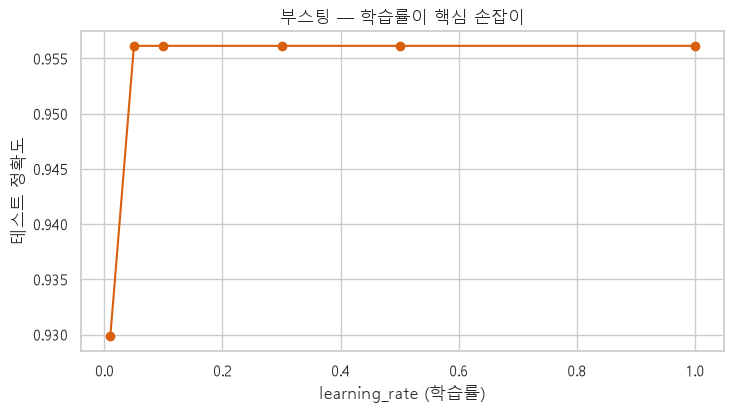

→ 너무 크면 불안정·과적합, 너무 작으면 더 많은 트리가 필요합니다(트레이드오프).


In [73]:
# ─────────────────────────────────────────────
# [C17] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 학습률(learning_rate)이 부스팅에 미치는 영향
# ─────────────────────────────────────────────
lrs = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
acc_lr = [GradientBoostingClassifier(n_estimators=200, learning_rate=lr, max_depth=3,
          random_state=RANDOM_STATE).fit(Xc_tr, yc_tr).score(Xc_te, yc_te) for lr in lrs]
plt.figure(figsize=(7.5, 4.3))
plt.plot(lrs, acc_lr, "o-", color="#d95f0e")
plt.xlabel("learning_rate (학습률)"); plt.ylabel("테스트 정확도")
plt.title("부스팅 — 학습률이 핵심 손잡이")
plt.tight_layout(); plt.show()
print("→ 너무 크면 불안정·과적합, 너무 작으면 더 많은 트리가 필요합니다(트레이드오프).")

## [문제]

- 지금까지 만든 5개 모델(단일트리·RF·AdaBoost·GBM·XGBoost)의 테스트 정확도를 한 줄씩 출력해 비교해보세요.

In [83]:
print(f"단일 트리 테스트 정확도 = {single.score(Xc_te,yc_te):.3f}")
print(f"랜덤 포레스트 테스트 정확도 = {rf.score(Xc_te, yc_te):.3f}")
print(f"AdaBoost 테스트 정확도 = {ada.score(Xc_te, yc_te):.3f}")
print(f"GBM 테스트 정확도 = {gbm.score(Xc_te, yc_te):.3f}")
print(f"XGBoost 테스트 정확도 = {xgb.score(Xc_te, yc_te):.3f}")


단일 트리 테스트 정확도 = 0.912
랜덤 포레스트 테스트 정확도 = 0.947
AdaBoost 테스트 정확도 = 0.965
GBM 테스트 정확도 = 0.956
XGBoost 테스트 정확도 = 0.947


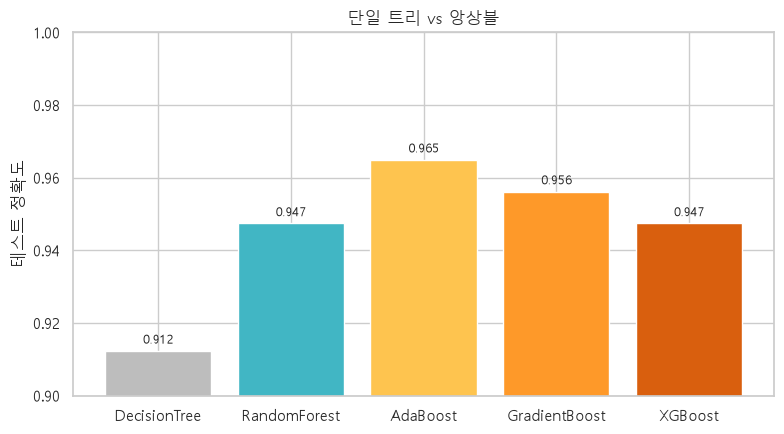

→ 앙상블(특히 부스팅)이 단일 트리보다 대체로 높고 안정적입니다.


In [ ]:
# ─────────────────────────────────────────────
# [C19] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 성능과 중요도를 한자리에 모델별 테스트 정확도 비교
# ─────────────────────────────────────────────
names = ["DecisionTree", "RandomForest", "AdaBoost", "GradientBoost", "XGBoost"]
models = [single, rf, ada, gbm, xgb]
accs = [m.score(Xc_te, yc_te) for m in models] #정확도

plt.figure(figsize=(8, 4.5))
bars = plt.bar(names, accs, color=["#bdbdbd", "#41b6c4", "#fec44f", "#fe9929", "#d95f0e"])
plt.ylim(0.9, 1.0); plt.ylabel("테스트 정확도")
plt.title("단일 트리 vs 앙상블")
for b, a in zip(bars, accs):
    plt.text(b.get_x()+b.get_width()/2, a+0.002, f"{a:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print("→ 앙상블(특히 부스팅)이 단일 트리보다 대체로 높고 안정적입니다.")

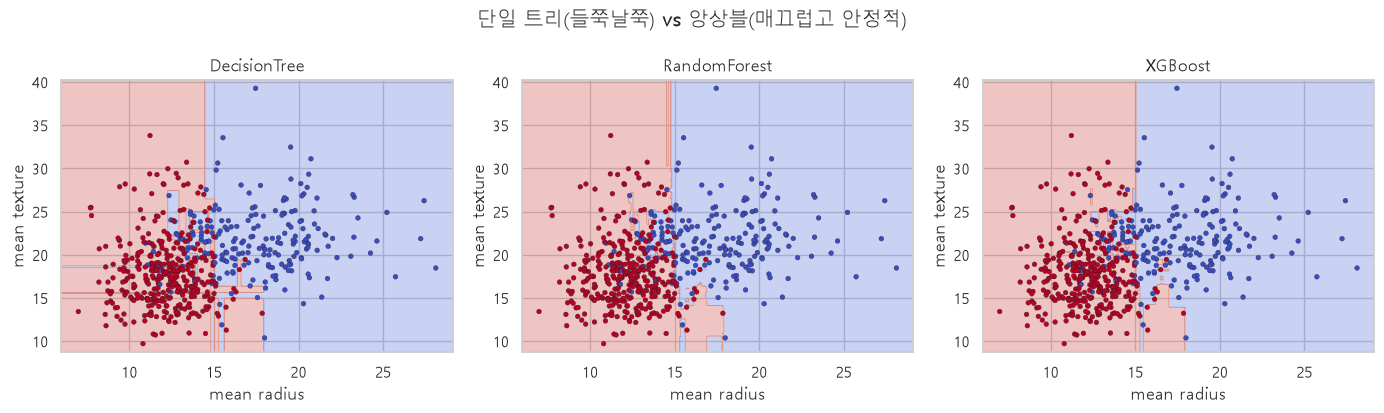

In [85]:
# ─────────────────────────────────────────────
# [C20] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 성능과 중요도를 한자리에 결정경계 비교 — Tree / RandomForest / XGBoost
# ─────────────────────────────────────────────
import numpy as np
feats = ["mean radius", "mean texture"]
X2 = Xc[feats].values
xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-1, X2[:,0].max()+1, 300),
                     np.linspace(X2[:,1].min()-1, X2[:,1].max()+1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

models2 = [("DecisionTree", DecisionTreeClassifier(max_depth=None, random_state=42)),
           ("RandomForest", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
           ("XGBoost", XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4,
                                     random_state=42, eval_metric="logloss"))]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (name, m) in zip(axes, models2):
    m.fit(X2, yc)
    zz = m.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap="coolwarm")
    ax.scatter(X2[:,0], X2[:,1], c=yc, cmap="coolwarm", s=12, edgecolor="k", linewidth=0.2)
    ax.set_title(name); ax.set_xlabel(feats[0]); ax.set_ylabel(feats[1])
plt.suptitle("단일 트리(들쭉날쭉) vs 앙상블(매끄럽고 안정적)")
plt.tight_layout(); plt.show()

#### [C20] 읽는 법: 단일 트리는 경계가 각지고 과적합돼 보이지만, 랜덤포레스트·XGBoost는 여러 나무를 종합해 더 부드럽고 일반화된 경계를 만듭니다. 

##### 같은 데이터인데 "여러 모델을 모으면" 경계가 안정되는 걸 눈으로 확인할 수 있습니다. 이것이 오늘의 핵심 — "여러 모델을 모으면 더 강해진다."

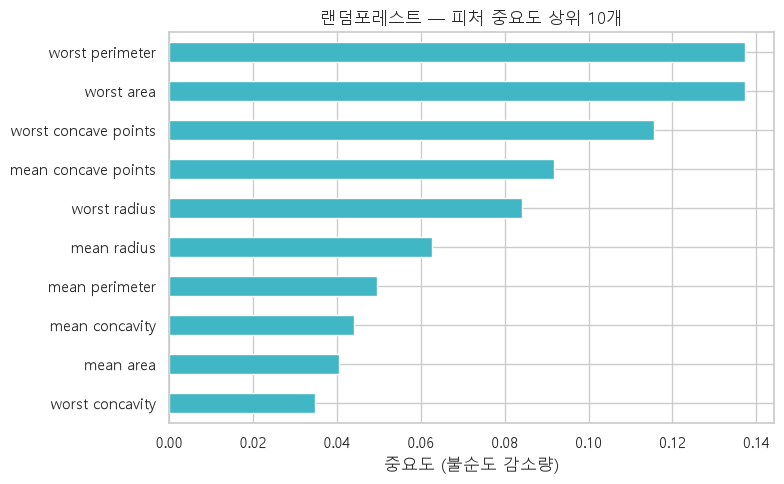

가장 중요한 피처 Top 5:
worst perimeter         0.137344
worst area              0.137312
worst concave points    0.115502
mean concave points     0.091774
worst radius            0.084111
dtype: float64


In [88]:
# ─────────────────────────────────────────────
# [C21] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 성능과 중요도를 한자리에 피처 중요도 — 어떤 피처가 예측을 이끄는가 (랜덤포레스트)
# ─────────────────────────────────────────────
imp = pd.Series(rf.feature_importances_, index=Xc.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
imp[::-1].plot(kind="barh", color="#41b6c4")
plt.title("랜덤포레스트 — 피처 중요도 상위 10개")
plt.xlabel("중요도 (불순도 감소량)")
plt.tight_layout(); plt.show()
print("가장 중요한 피처 Top 5:")
print(imp.head(5))

In [87]:
# ─────────────────────────────────────────────
# [C22] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 성능과 중요도를 한자리에 순열 중요도 — 피처를 섞으면 성능이 얼마나 떨어지나
# ─────────────────────────────────────────────
from sklearn.inspection import permutation_importance
perm = permutation_importance(rf, Xc_te, yc_te, n_repeats=10, random_state=RANDOM_STATE)
perm_imp = pd.Series(perm.importances_mean, index=Xc.columns).sort_values(ascending=False).head(5)
print("순열 중요도 Top 5 (섞었을 때 정확도 하락폭):")
print(perm_imp.round(4))
print("\n→ 불순도 기반과 순열 기반의 순위를 비교해 보세요. 대체로 비슷하지만 다를 수 있습니다.")

순열 중요도 Top 5 (섞었을 때 정확도 하락폭):
mean concave points       0.0026
mean radius               0.0000
mean fractal dimension    0.0000
radius error              0.0000
mean area                 0.0000
dtype: float64

→ 불순도 기반과 순열 기반의 순위를 비교해 보세요. 대체로 비슷하지만 다를 수 있습니다.


- [C23] ◀ Part 5 · ⌨️ 백문이 불여일타! (5) ⌨️ 백문이 불여일타! (5) — 두 중요도의 Top 5 비교

[문제]
1) 불순도 기반 중요도(feature_importances_)와 순열 중요도(permutation_importance)의 Top 5 피처 순위가 같은지 비교해보세요.

가장 중요한 피처 Top 5:
worst perimeter         0.137344
worst area              0.137312
worst concave points    0.115502
mean concave points     0.091774
worst radius            0.084111

순열 중요도 Top 5 (섞었을 때 정확도 하락폭):
mean concave points       0.0026
mean radius               0.0000
mean fractal dimension    0.0000
radius error              0.0000
mean area                 0.0000
dtype: float64

2) 순위가 다르다면 왜 그럴지 생각해보세요.
계수는 "모델이 무엇을 학습했는가", 순열 중요도는 "그 피처가 없으면 모델이 얼마나 못 맞추는가"를 보는 거라서, 특히 피처 간 상관관계가 있을 때 둘의 순위가 어긋나는 게 정상입니다.


In [90]:
feat_imp = pd.Series(rf.feature_importances_, index=Xc.columns).sort_values(ascending=False).head(5)
perm_imp = pd.Series(perm.importances_mean, index=Xc.columns).sort_values(ascending=False).head(5)
print("불순도 기반 중요도 Top 5:")
print(feat_imp.index.tolist()[:5])
print("\n순열 중요도 Top 5 (섞었을 때 정확도 하락폭):")
print(perm_imp.index.tolist()[:5])

불순도 기반 중요도 Top 5:
['worst perimeter', 'worst area', 'worst concave points', 'mean concave points', 'worst radius']

순열 중요도 Top 5 (섞었을 때 정확도 하락폭):
['mean concave points', 'mean radius', 'mean fractal dimension', 'radius error', 'mean area']


1. 특성 중요도(Feature Importance)
각 특성별로 모든 트리에 대해 평균불순도감소(mean decrease impurity)를 계산한 값. 특성을 중요한 것부터 나열

2. 순열 중요도(Permutation Importance)

특정 변수를 무작위로 섞어(permutate) 해당 변수가 가진 정보의 구조를 깨뜨립니다.
이로 인해 모델의 예측 성능이 얼마나 감소하는지를 측정합니다.
성능이 크게 감소한다면 해당 변수는 중요한 변수로 간주됩니다.

Q. 순열 중요도가 낮은데 실제로는 중요한 피처가 될 수 있다. 어떤 케이스 일까?
A. 특성 상호작용
ex) 심장병 여부 -> 음주 횟수, 간 수치 -> 하나를 못쓰게 만들어서 하나가 살아있어서,, 성능 저하를 볼 수 없다.


개념 퀴즈
▸
배깅과 부스팅의 학습 방식 차이(병렬/순차)를 한 문장으로 설명하세요.
▸배깅은 병렬적으로 학습하고, 부스팅은 잔차를 순차적으로 학습합니다.
Gradient Boosting의 각 트리는 무엇을 예측하나요?
▸ 잔차를 학습
트리 계열에 표준화가 대체로 불필요한 이유는?
▸ 트리는 "크기"가 아니라 "분기 기준(크다/작다)"으로 나누기 때문에 단위에 둔감합니다.
"성능이 가장 높은 XGBoost를 항상 써야 한다"는 맞는 말일까요?
▸ No. 랜덤포레스트를 베이스라인으로 먼저 돌려보세요(튜닝 거의 불필요, 안정적). 더 성능을 짜내야 하면 XGBoost로 넘어가 튜닝합니다.
